# COMP4670/8600 - Statistical Machine Learning #
## Assignment 1 - Bias, Variance and Bayesian Thinking ##

In [23]:
import matplotlib
matplotlib.rcParams['text.usetex'] = False

**TODO: put your name and uid here**

*uid:* u8076655

*name:* RUI LUO

### Section 0 ###

**Question 0.1**


We start from Bayes' rule:
$$
p(\mu \mid x_{1:n}) \propto p(x_{1:n}\mid \mu)\,p(\mu).
$$

The likelihood is
$$
p(x_{1:n}\mid \mu)
=
\prod_{i=1}^n \mathcal{N}(x_i\mid \mu,\sigma^2)
\propto
\prod_{i=1}^n
\exp\!\left(
-\frac{1}{2\sigma^2}(x_i-\mu)^2
\right)
=
\exp\!\left(
-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2
\right).
$$

The prior is
$$
p(\mu)=\mathcal{N}(\mu\mid \eta,\beta^{-1})
\propto
\exp\!\left(
-\frac{\beta}{2}(\mu-\eta)^2
\right).
$$

Therefore,
$$
p(\mu \mid x_{1:n})
\propto
\exp\!\left(
-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2
-\frac{\beta}{2}(\mu-\eta)^2
\right).
$$

Expanding the first quadratic term:
$$
\sum_{i=1}^n (x_i-\mu)^2
=
\sum_{i=1}^n (\mu^2-2\mu x_i+x_i^2).
$$

So
$$
p(\mu \mid x_{1:n})
\propto
\exp\!\left(
-\frac{1}{2\sigma^2}\sum_{i=1}^n (\mu^2-2\mu x_i+x_i^2)
-\frac{\beta}{2}(\mu^2-2\eta\mu+\eta^2)
\right).
$$

Expanding and grouping terms gives
$$
p(\mu \mid x_{1:n})
\propto
\exp\!\left(
-\frac{n\mu^2}{2\sigma^2}
+\frac{\mu}{\sigma^2}\sum_{i=1}^n x_i
-\frac{1}{2\sigma^2}\sum_{i=1}^n x_i^2
-\frac{\beta}{2}\mu^2
+\beta\eta\mu
-\frac{\beta}{2}\eta^2
\right).
$$

Rearranging,
$$
p(\mu \mid x_{1:n})
\propto
\exp\!\left(
-\frac{1}{2}\left(\frac{n}{\sigma^2}+\beta\right)\mu^2
+
\left(
\frac{\sum_{i=1}^n x_i}{\sigma^2}+\beta\eta
\right)\mu
-\frac{1}{2\sigma^2}\sum_{i=1}^n x_i^2
-\frac{\beta}{2}\eta^2
\right).
$$

Let
$$
C=
-\frac{1}{2\sigma^2}\sum_{i=1}^n x_i^2-\frac{\beta}{2}\eta^2,
$$
which is a constant independent of $\mu$.

Hence,
$$
p(\mu \mid x_{1:n})
\propto
C\cdot
\exp\!\left(
-\frac{1}{2}
\left[
\left(\frac{n}{\sigma^2}+\beta\right)\mu^2
-
2\left(
\frac{\sum_{i=1}^n x_i}{\sigma^2}+\beta\eta
\right)\mu
\right]
\right).
$$

Now define
$$
A=\frac{n}{\sigma^2}+\beta,
\qquad
B=\frac{\sum_{i=1}^n x_i}{\sigma^2}+\beta\eta
=
\frac{n\bar{x}}{\sigma^2}+\beta\eta.
$$

Then
$$
p(\mu \mid x_{1:n})
\propto
\exp\!\left(
-\frac{1}{2}(A\mu^2-2B\mu)
\right).
$$

Complete the square:
$$
A\mu^2-2B\mu
=
A\left(\mu-\frac{B}{A}\right)^2-\frac{B^2}{A}.
$$

Therefore,
$$
p(\mu \mid x_{1:n})
\propto
\exp\!\left(
-\frac{A}{2}\left(\mu-\frac{B}{A}\right)^2
-\frac{B^2}{A}
\right)
\propto
\exp\!\left(
-\frac{A}{2}\left(\mu-\frac{B}{A}\right)^2
\right).
$$

So the posterior is Gaussian:
$$
p(\mu \mid x_{1:n})
=
\mathcal{N}\!\left(\mu \,\middle|\, \frac{B}{A}, \frac{1}{A}\right).
$$

Substituting back $A$ and $B$,
$$
p(\mu \mid x_{1:n})
=
\mathcal{N}\!\left(
\mu \,\middle|\,
\frac{\beta\eta+\frac{n}{\sigma^2}\bar{x}}{\beta+\frac{n}{\sigma^2}},
\left(\beta+\frac{n}{\sigma^2}\right)^{-1}
\right).
$$

Since the posterior is Gaussian, the MAP estimate is its mean:
$$
\mu^*_{\mathrm{MAP}}
=
m_N
=
\frac{\beta\eta+\frac{n}{\sigma^2}\bar{x}}{\beta+\frac{n}{\sigma^2}}.
$$

**Question 0.2**

Yes. A **constant (flat) prior** makes the MAP estimate equal to the MLE estimate.

Recall that
$$
\theta_{\mathrm{MLE}} = \arg\max_{\theta} p(D \mid \theta),
$$
while
$$
\theta_{\mathrm{MAP}} = \arg\max_{\theta} p(\theta \mid D).
$$

By Bayes' rule,
$$
p(\theta \mid D) \propto p(D \mid \theta)\,p(\theta).
$$
Therefore,
$$
\theta_{\mathrm{MAP}}
= \arg\max_{\theta} p(D \mid \theta)\,p(\theta).
$$

Now choose a flat prior
$$
p(\theta) \propto 1.
$$
Then
$$
\theta_{\mathrm{MAP}}
= \arg\max_{\theta} p(D \mid \theta)\cdot c
= \arg\max_{\theta} p(D \mid \theta)
= \theta_{\mathrm{MLE}}.
$$

Hence, a constant prior makes MAP and MLE identical.

This is not specific to Gaussian estimation. The argument does not depend on the form of the likelihood, only on the prior being constant. Therefore, the same conclusion applies to any parametric distribution.

If the posterior is Gaussian, then the MAP estimate (the mode of the posterior) is equal to the posterior mean, so the sample mean of posterior draws can be used to approximate MAP. If the posterior is not Gaussian, this approximation does not necessarily hold.

**Question 0.3**


Let
$$
\bar{\theta}=\frac{1}{N}\sum_{i=1}^N \theta_i,
\qquad
\theta_{\text{MAP}}=\arg\max_{\theta\in\Theta} p(\theta\mid D).
$$

Since
$$
\bar{\theta}\approx \mathbb{E}[\theta\mid D],
$$
the key property is whether the posterior mean is close to the posterior mode.

i. The sample mean is a good approximation to MAP when the posterior is approximately Gaussian

- unimodal
- approximately symmetric
- concentrated around one main high-density region

Also, in the large-sample setting, the posterior is often approximately Gaussian, because with more data it concentrates around one parameter value, and locally the log-posterior becomes approximately quadratic.

In particular, if
$$
p(\theta\mid D)\approx \mathcal{N}(\mu,\Sigma),
$$
then
$$
\theta_{\text{MAP}}=\mu=\mathbb{E}[\theta\mid D],
$$
so
$$
\bar{\theta}\approx \theta_{\text{MAP}}.
$$

Also, in the large-sample setting, the posterior is often approximately Gaussian, so the sample mean can still be a reasonable approximation to MAP.

ii. Conversely, the sample mean is a poor approximation to MAP when the posterior is not approximately Gaussian

- multimodal
- highly skewed
- heavy-tailed

In such cases,
$$
\mathbb{E}[\theta\mid D]
$$
can be far from the posterior mode, so
$$
\bar{\theta}\not\approx \theta_{\text{MAP}}.
$$

**Question 0.4**

For the sample mean

$$
\bar{\theta}=\frac{1}{N}\sum_{i=1}^N \theta_i,
$$

a natural way to construct error bars is to estimate the **standard error of the mean** from the samples:

$$
s^2=\frac{1}{N-1}\sum_{i=1}^N (\theta_i-\bar{\theta})^2,
\qquad
\mathrm{SE}(\bar{\theta})=\frac{s}{\sqrt{N}}.
$$

So we can place error bars around $\bar{\theta}$ using its estimated standard error.

For the sample maximum

$$
\hat{\theta}*{\max}=\arg\max*{i=1,\dots,N} p(\theta_i\mid D),
$$

A possible way is to use a local highest-posterior-density region around the sample maximum, i.e. collect samples whose posterior probabilities are close to the maximum and use their spread to form an uncertainty interval.

If the posterior is approximately smooth and unimodal near the mode, a Laplace approximation can be used instead, where the local Hessian determines the error bars.

However, if samples are sparse near the mode or the posterior is multimodal, a single error bar may be misleading; in that case one should report multiple high-density regions or use more robust multimodal posterior exploration methods such as tempering or nested sampling.


### Section 1 ###

In [2]:
### DO NOT CHANGE: this block contains utility code provided for this assignment 
### 

import numpy as np
import matplotlib.pyplot as plt

# Config 
# -----------------------------
seed_value = 2026
x_min, x_max = -3.0, 3.0
noise_std = 0.5   # observation noise for regression targets

# -----------------------------
# Target function h(x) definition
# -----------------------------

def h_func(x, mu=0.0, sigma=1.0):
    return 10 * np.sin(x) * np.exp( - ((x - mu) / sigma)**2)

# Dense grid for this task
x_grid = np.linspace(x_min, x_max, 1000)

# fix random seed
current_rng = np.random.default_rng(seed_value)

# -----------------------------
# Create a sample regression dataset
# -----------------------------
def sample_dataset(N=100, noise_std=0.1, rng=None, x_min=-3, x_max=3):
    if rng is None:
        rng = np.random.default_rng(42)
    x_samples = rng.uniform(x_min, x_max, size=N)
    y_true = h_func(x_samples)
    y_noisy = y_true + rng.normal(0, noise_std, size=N)
    return x_samples, y_noisy

def sample_dataset_lognormal(N=100, mu=-1, noise_std=0.1, rng=None, x_min=-3, x_max=3):
    if rng is None:
        rng = np.random.default_rng(42)
    x_samples = rng.uniform(x_min, x_max, size=N)
    y_true = h_func(x_samples)
    # sample noise from a log-normal distribution, and multiply by a coin flip to allow for both positive and negative noise  
    y_noisy = y_true + rng.lognormal(mean=mu, sigma=noise_std, size=N) * rng.choice([-1, 1], size=N)
    return x_samples, y_noisy

# -----------------------------
# plotting function
# -----------------------------
def plot_regression_model(x, h, x_samples=[], y_noisy=[], line_color='navy', line_style='-', line_label='h(x) = exp(-x^2)· sin(x)', line_width=2):
    plt.plot(x, h, label=line_label, color=line_color, linestyle=line_style, linewidth=line_width)
    if len(x_samples) and len(y_noisy):
        plt.scatter(x_samples, y_noisy, s=18, color='tomato', alpha=0.6, label='Noisy samples')
    plt.axhline(0, color='gray', linewidth=0.8)
    plt.axvline(0, color='gray', linewidth=0.8)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(x_min, x_max)
    plt.ylim(-5, 5)
    plt.tight_layout()

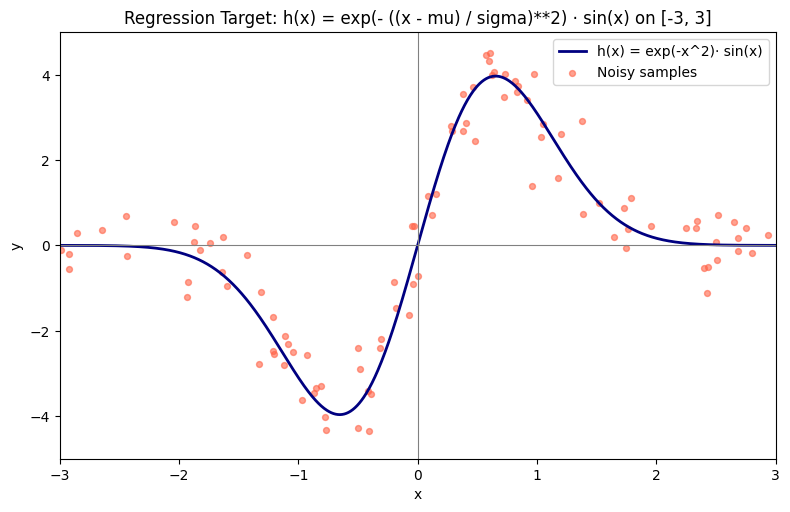

x=-1.926, y_noisy=-0.870, h=-0.229
x= 0.839, y_noisy= 3.737, h= 3.679
x=-0.196, y_noisy=-0.861, h=-1.877


In [3]:

h_grid = h_func(x_grid)

# generate a training dataset 
x_samples, y_noisy = sample_dataset(N=100, noise_std=noise_std, rng=current_rng)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))
plot_regression_model(x_grid, h_grid, x_samples, y_noisy)
plt.title('Regression Target: h(x) = exp(- ((x - mu) / sigma)**2) · sin(x) on [-3, 3]')
plt.legend()
plt.show()

# Optional: preview a few sample pairs
for i in range(3):
    print(f"x={x_samples[i]: .3f}, y_noisy={y_noisy[i]: .3f}, h={h_func(x_samples[i]): .3f}")


**Question 1.1**

In [4]:
# -----------------------------
### TODO: generate nth-order polynomial feature matrix
# -----------------------------
def poly_features(x, degree=8):
    # Construct Vandermonde feature matrix Φ ∈ R^{N × (degree+1)}
    # Φ = [[1, x1, x1^2, ..., x1^d],
    #       [1, x2, x2^2, ..., x2^d],
    #       ...
    #       [1, xN, xN^2, ..., xN^d]]
    x = np.asarray(x).reshape(-1)                                # ensure x is 1D, shape (N,)
    return np.column_stack([x ** d for d in range(degree + 1)])  # shape (N, degree+1)

# -----------------------------
### TODO: calculate the MLE solution
# -----------------------------
def theta_MLE(x, y, degree=8):
    # MLE solution minimises the residual sum of squares: ||Φθ - y||^2
    # Closed-form solution (Normal Equations): θ = (Φ^T Φ)^{-1} Φ^T y = Φ^+ y
    # where Φ^+ is the Moore-Penrose pseudoinverse of Φ
    phix = poly_features(x, degree=degree)  # Φ, shape (N, degree+1)
    y = np.asarray(y).reshape(-1)           # y, shape (N,)
    theta = np.linalg.pinv(phix) @ y       # θ = Φ^+ y, shape (degree+1,)
    return theta


# -----------------------------
### TODO: make prediction given input *feature* and model parameters
# -----------------------------
def predict(phix, theta):
    # Linear prediction: ŷ = Φ θ
    # ŷ_i = θ_0 + θ_1 x_i + θ_2 x_i^2 + ... + θ_d x_i^d
    phix = np.asarray(phix)                # Φ, shape (N, degree+1)
    theta = np.asarray(theta).reshape(-1)  # θ, shape (degree+1,)
    return phix @ theta                    # ŷ, shape (N,)

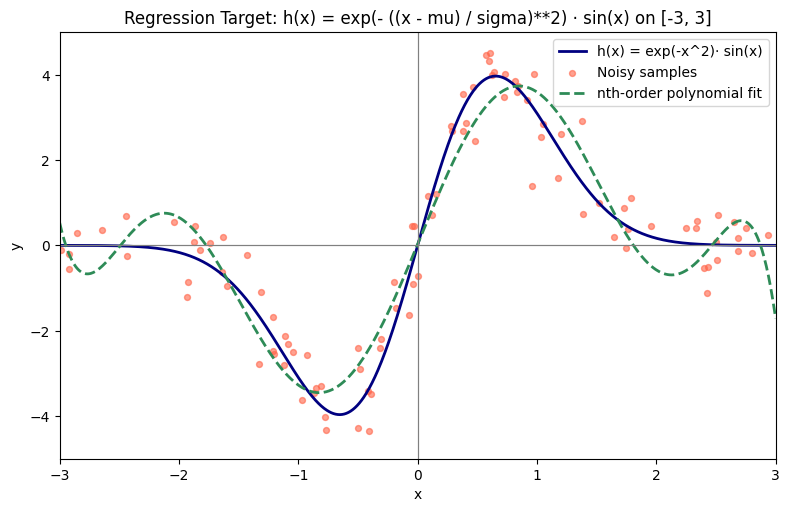

Coefficients theta (from degree 0 to 5):
[ 2.66671750e-02  6.76005726e+00  2.50461311e-01 -4.00929603e+00
 -1.42492849e-01  7.23180161e-01  2.67920328e-02 -4.06422594e-02
 -1.65553242e-03]

Training MSE and RMSE: (0.5831083740423099, 0.7636153311990991)


In [5]:
# Q1.1 test, do not change

phix_train = poly_features(x_samples, degree=8)
phix_grid = poly_features(x_grid, degree=8)
theta = theta_MLE(x_samples, y_noisy)

y_pred_train = predict(phix_train, theta)
y_pred_grid = predict(phix_grid, theta)


mse_train = np.mean((y_pred_train - y_noisy)**2)
rmse_train = np.sqrt(np.mean((y_pred_train - y_noisy)**2))


plt.figure(figsize=(8,5))
plot_regression_model(x_grid, h_grid, x_samples, y_noisy)
plot_regression_model(x_grid, y_pred_grid, line_color='seagreen', line_style='--', line_label='nth-order polynomial fit')
plt.legend()
plt.title('Regression Target: h(x) = exp(- ((x - mu) / sigma)**2) · sin(x) on [-3, 3]')
plt.show()

print('Coefficients theta (from degree 0 to 5):')
print(theta)
print('\nTraining MSE and RMSE:', (mse_train, rmse_train))


**Question 1.2**

Q1.2(a)

The three quantities are

$$
(\mathrm{bias})^2
=
\int \big(\mathbb{E}_D[y(x;D)] - h(x)\big)^2 \, p(x)\, dx,
$$

$$
\mathrm{variance}
=
\int \mathbb{E}_D\!\left[\big(y(x;D)-\mathbb{E}_D[y(x;D)]\big)^2\right] p(x)\, dx,
$$

$$
\mathrm{noise}
=
\iint (h(x)-t)^2 \, p(x,t)\, dx\, dt.
$$

In general, these terms do not admit analytical closed-form solutions, because they are defined as expectations over distributions rather than as quantities computed from one fixed dataset.

To obtain an analytical solution, we would need to evaluate these expectations exactly.

For the noise term, this means integrating over the joint distribution $p(x,t)$.

For the bias and variance terms, this is harder, because they also involve $\mathbb{E}_D[y(x;D)]$, which is an expectation over all possible training datasets $D$.

Moreover, $y(x;D)$ is the predictor obtained after training on dataset $D$, so it depends on the random dataset through the learning procedure and is typically a nonlinear function of $D$.

Since expectation only interacts simply with linear operations, but in general $\mathbb{E}[g(D)] \neq g(\mathbb{E}[D])$ for nonlinear $g$, these integrals usually cannot be simplified into closed-form expressions.

Therefore, bias, variance, and noise are usually estimated empirically using finitely many sampled training datasets and test points.

Q1.2(b):

### (b)

Yes

In this question, the underlying function h(x) is fixed for this question by Equation $(2.1)$, $x$ is sampled i.i.d. from a uniform distribution on $[-3,3]$, and $t$ is a noisy version of $h(x)$. The bias-variance setup also assumes that training and test datasets are drawn from the same underlying distribution. Hence, the test pairs

$$
\{(x_i,t_i)\}_{i=1}^M
$$

can be viewed as samples from the joint distribution $p(x,t)$.

The noise term is

$$
\mathrm{noise}
=
\iint
\left(h(x)-t\right)^2 p(x,t)\,dx\,dt
=
\mathbb{E}_{(x,t)\sim p(x,t)}
\left[
\left(h(x)-t\right)^2
\right].
$$

Let

$$
g(x,t)=\left(h(x)-t\right)^2.
$$

Then

$$
\mathrm{noise}=\mathbb{E}[g(x,t)].
$$

Therefore, the test-set average

$$
\mathrm{noise\_estimate}
=
\frac{1}{M}\sum_{i=1}^M \left(h(x_i)-t_i\right)^2
$$

is a sample-average approximation to this expectation. More formally,

$$
\mathbb{E}[\mathrm{noise\_estimate}]
=
\mathbb{E}\left[
\frac{1}{M}\sum_{i=1}^M g(x_i,t_i)
\right]
=
\frac{1}{M}\sum_{i=1}^M \mathbb{E}[g(x_i,t_i)]
=
\mathbb{E}[g(x,t)]
=
\mathrm{noise}.
$$

Also, by the law of large numbers,

$$
\mathrm{noise\_estimate}\to \mathrm{noise}
\qquad \text{as } M\to\infty.
$$

Hence,

$$
\mathrm{noise\_estimate}
=
\frac{1}{M}\sum_{i=1}^M \left(h(x_i)-t_i\right)^2
\approx
\iint
\left(h(x)-t\right)^2 p(x,t)\,dx\,dt.
$$

So Equation (2.2) is correct as a sample-average approximation, but it is not exactly equal to the double integral for finite $M$.

Q1.2(c): 

The bias-squared quantity is :

$$(\mathrm{bias})^2 = \int \left( \mathbb{E}_D[y(x;D)] - h(x) \right)^2 p(x)\,dx$$

Approximate $\mathbb{E}_D[y(x_i;D)]$ by averaging predictions from $K$ models:

$$
\mathbb{E}_D[y(x_i;D)] \approx \frac{1}{K}\sum_{k=1}^K y(x_i;\theta_k).
$$

Then the test-set approximation is

$$
\widehat{(\mathrm{bias})^2}
=
\frac{1}{M}\sum_{i=1}^{M}
\left(
\frac{1}{K}\sum_{k=1}^{K} y(x_i;\theta_k) - h(x_i)
\right)^2.
$$

(Use $h(x_i)$, not $t_i$, since $t_i$ includes noise.)

Q1.2(d):

From the definition,

$$
\mathrm{variance}
=
\int
\mathbb{E}_D
\left[
\left(
y(x;D)-\mathbb{E}_D[y(x;D)]
\right)^2
\right]
p(x)\,dx
$$

For a fixed test input $x_i$,

$$
V(x_i)
=
\mathbb{E}_D
\left[
\left(
y(x_i;D)-\mathbb{E}_D[y(x_i;D)]
\right)^2
\right]
$$

Using $K$ models to approximate the mean prediction,

$$
\mathbb{E}_D[y(x_i;D)]
\approx
\frac{1}{K}\sum_{k=1}^{K} y(x_i;\theta_k)
$$

Thus,

$$
V(x_i)
\approx
\frac{1}{K}\sum_{k=1}^{K}
\left(
y(x_i;\theta_k)
-
\frac{1}{K}\sum_{j=1}^{K} y(x_i;\theta_j)
\right)^2
$$

Using $M$ test inputs to approximate the integral over $p(x)$,

$$
\widehat{\mathrm{variance}}
=
\frac{1}{M}\sum_{i=1}^{M} V(x_i)
$$

Therefore,

$$
\widehat{\mathrm{variance}}
=
\frac{1}{M}\sum_{i=1}^{M}
\left[
\frac{1}{K}\sum_{k=1}^{K}
\left(
y(x_i;\theta_k)
-
\frac{1}{K}\sum_{j=1}^{K} y(x_i;\theta_j)
\right)^2
\right]
$$

**Question 1.3**

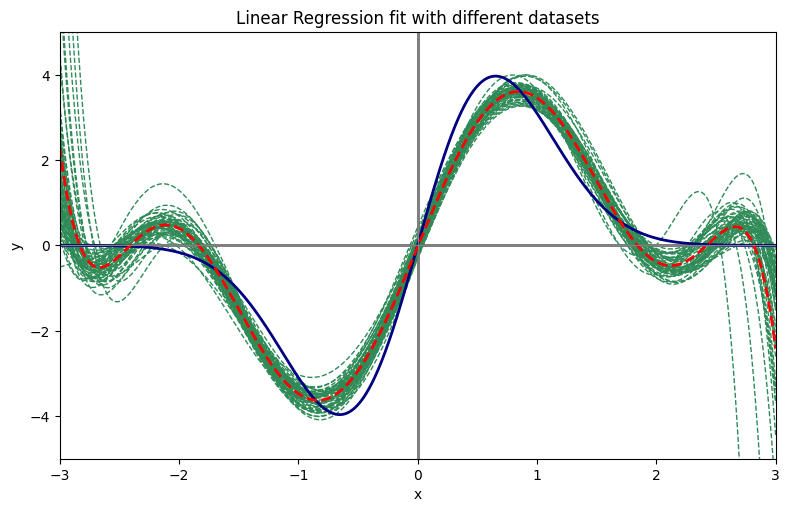

In [6]:
# Sample a bunch (NUM_DATASETS=50) of training datasets, and fit a regression model for each dataset.
# We will then plot the average fitted curve across all datasets, and compare it with the original h(x) function.

datasets_train = []
datasets_test = []
weights = []

NUM_DATASETS = 50

for _ in range(NUM_DATASETS):
    x_samples, y_noisy = sample_dataset(N=100, noise_std=noise_std, rng=current_rng)
    datasets_train.append((x_samples, y_noisy))

y_pred_grid_avg = np.zeros_like(x_grid)
plt.figure(figsize=(8,5))

# we now fit the regression function for each dataset, and compute the expected y value at each grid point
for x_train, y_train in datasets_train:
    # TODO: Fit the model
    theta = theta_MLE(x_train, y_train, degree=8)
    # TODO: update the weights list
    weights.append(theta)

    # compute and plot each fitted curve 
    # TODO: predict y for the grid points
    y_pred_grid = predict(phix_grid, theta)
    y_pred_grid_avg += (1/NUM_DATASETS) * y_pred_grid
    plot_regression_model(x_grid, y_pred_grid, line_color='seagreen', line_style='--', line_label='', line_width=1)

# plot the original h(x) 
plot_regression_model(x_grid, h_grid)
# plot the average fitted curve
plot_regression_model(x_grid, y_pred_grid_avg, line_color='red', line_style='--')
plt.title('Linear Regression fit with different datasets')
plt.show()


In [7]:
# We now compute approximated bias, variance and noise

## Sample test dataset (1000 data points)
x_test, y_test = sample_dataset(N=1000, noise_std=noise_std, rng=current_rng)

### TODO: compute approximated bias, variance and noise

h_test = h_func(x_test)
phix_test = poly_features(x_test, degree=8)

K = len(weights)
M = len(x_test)

# all_preds[k, i] = y(x_i; theta_k)
all_preds = np.vstack([predict(phix_test, theta) for theta in weights])

# avg_pred[i] = (1/K) sum_k y(x_i; theta_k)
avg_pred = np.sum(all_preds, axis=0) / K

# (1/M) sum_i (avg_pred[i] - h(x_i))^2
est_bias2 = np.sum((avg_pred - h_test) ** 2) / M

# (1/M) sum_i (1/K) sum_k (y(x_i;theta_k) - avg_pred[i])^2
est_variance = np.sum(np.sum((all_preds - avg_pred[None, :]) ** 2, axis=0) / K) / M

# (1/M) sum_i (h(x_i) - t_i)^2
est_noise = np.sum((h_test - y_test) ** 2) / M

print('Test bias2, variance, noise:')
print(est_bias2, est_variance, est_noise)

Test bias2, variance, noise:
0.3235804961039155 0.609895249426436 0.24461338981850886


**Question 1.4**

Q1.4(a):

The noise term should be $\mathrm{noise}=\mathbb{E}[(h(x)-t)^2]=\mathbb{E}[\eta^2]=(0.5)^2=0.25$, and $\epsilon=\widehat{\mathrm{noise}}-0.25$ is the finite-sample approximation error.

Q1.4(b): 

Increase $M$ (the test set size), because $\widehat{\mathrm{noise}}=\frac{1}{M}\sum_{i=1}^M (h(x_i)-t_i)^2$ is a sample average and becomes more accurate for larger $M$.

Q1.4(c): 

Increase $M$, since the approximations of bias, variance, and noise are all empirical averages over the test dataset.

Q1.4(d): 

They should approximately add up to the expected test squared loss, i.e. $\widehat{\mathrm{bias}^2}+\widehat{\mathrm{variance}}+\widehat{\mathrm{noise}}\approx \mathbb{E}[(y(x;D)-t)^2]$.

**Question 1.5**

In [8]:
def compute_bias_variance(N_train, num_datasets, N_test=1000, degree=8,
                          feature_fn=None, mle_fn=None):
    """Train num_datasets models, return (bias², variance) on N_test test points.
    
    If feature_fn and mle_fn are provided, use them instead of the default
    poly_features and theta_MLE. This allows the same function to be used
    for both polynomial and Gaussian basis functions.
    """
    if feature_fn is None:
        feature_fn = lambda x: poly_features(x, degree=degree)
    if mle_fn is None:
        mle_fn = lambda x, y: theta_MLE(x, y, degree=degree)

    train_rng = np.random.default_rng(seed_value)      # training rng
    test_rng  = np.random.default_rng(seed_value + 1)  # fixed test rng, independent of training

    # collect weights from num_datasets models
    ws = []
    for _ in range(num_datasets):
        x_tr, y_tr = sample_dataset(N=N_train, noise_std=noise_std, rng=train_rng)
        ws.append(mle_fn(x_tr, y_tr))

    # test_rng is seeded independently from train_rng (seed_value+1 vs seed_value).
    # x_test, y_test are always drawn from the same random state,
    # regardless of how many training samples or datasets were generated beforehand.
    # If we used a single shared rng, the test set's starting position in the
    # random sequence would shift every time N_train or num_datasets changes,
    # making comparisons across settings unfair.
    x_test, y_test = sample_dataset(N=N_test, noise_std=noise_std, rng=test_rng)
    h_test    = h_func(x_test)
    phix_test = feature_fn(x_test)

    K, M = len(ws), len(x_test)
    all_preds = np.vstack([predict(phix_test, w) for w in ws])  # (K, M)
    avg_pred  = all_preds.mean(axis=0)                          # (M,)

    # bias²  = (1/M) Σᵢ (ȳᵢ - h(xᵢ))²
    bias2    = np.sum((avg_pred - h_test) ** 2) / M
    # variance = (1/M) Σᵢ (1/K) Σₖ (y(xᵢ;θₖ) - ȳᵢ)²
    variance = np.sum(np.sum((all_preds - avg_pred[None, :]) ** 2, axis=0) / K) / M
    return bias2, variance

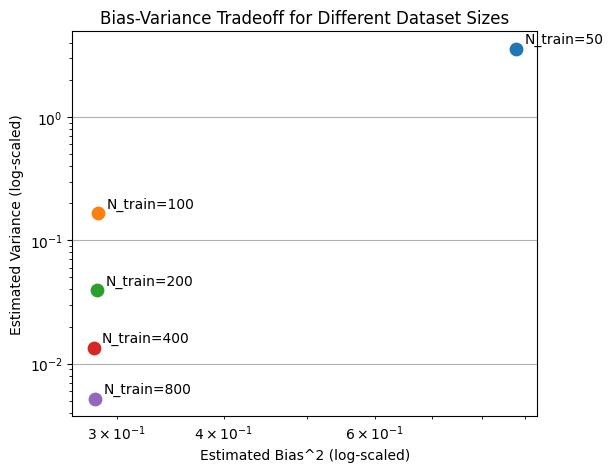

In [9]:
# Q1.5(a) - fixing num_datasets=20, varying N_train
NUM_DATASETSs = 20
N_trains = [50, 100, 200, 400, 800]
N_test = 1000

# TODO: bias2-variance scatter plot. Clearly label different settings.
plt.figure(figsize=(6, 5))
for N in N_trains:
    b2, var = compute_bias_variance(N_train=N, num_datasets=NUM_DATASETSs, N_test=N_test)
    plt.scatter(b2, var, s=80)
    plt.annotate(f'N_train={N}', (b2, var), textcoords='offset points', xytext=(6, 4))


plt.xlabel('Estimated Bias^2 (log-scaled)')
plt.ylabel('Estimated Variance (log-scaled)')

plt.xscale('log')
plt.yscale('log')

plt.title('Bias-Variance Tradeoff for Different Dataset Sizes')
# plt.legend()
plt.grid()
plt.show()

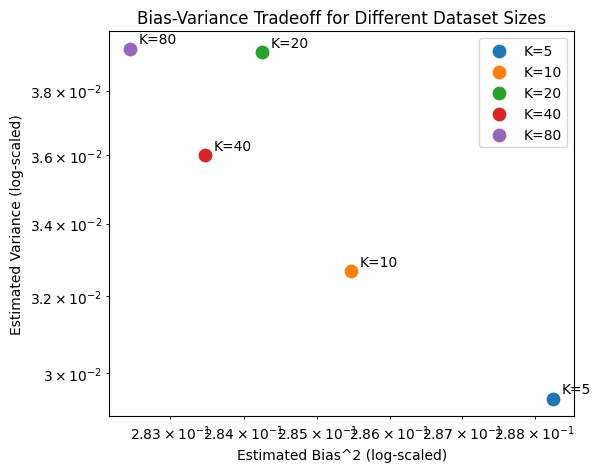

In [10]:
# Q1.5(a) - fixing N_train=200, varying num datasets
NUM_DATASETSs = [5, 10, 20, 40, 80]
N_trains = 200
N_test = 1000

# TODO: bias2-variance scatter plot. Clearly label different settings.

plt.figure(figsize=(6, 5))
for K in NUM_DATASETSs:
    b2, var = compute_bias_variance(N_train=N_trains, num_datasets=K, N_test=N_test)
    plt.scatter(b2, var, s=80, label=f'K={K}')
    plt.annotate(f'K={K}', (b2, var), textcoords='offset points', xytext=(6, 4))

plt.xlabel('Estimated Bias^2 (log-scaled)')
plt.ylabel('Estimated Variance (log-scaled)')

plt.xscale('log')
plt.yscale('log')

plt.title('Bias-Variance Tradeoff for Different Dataset Sizes')
plt.legend()
plt.grid()
plt.show()


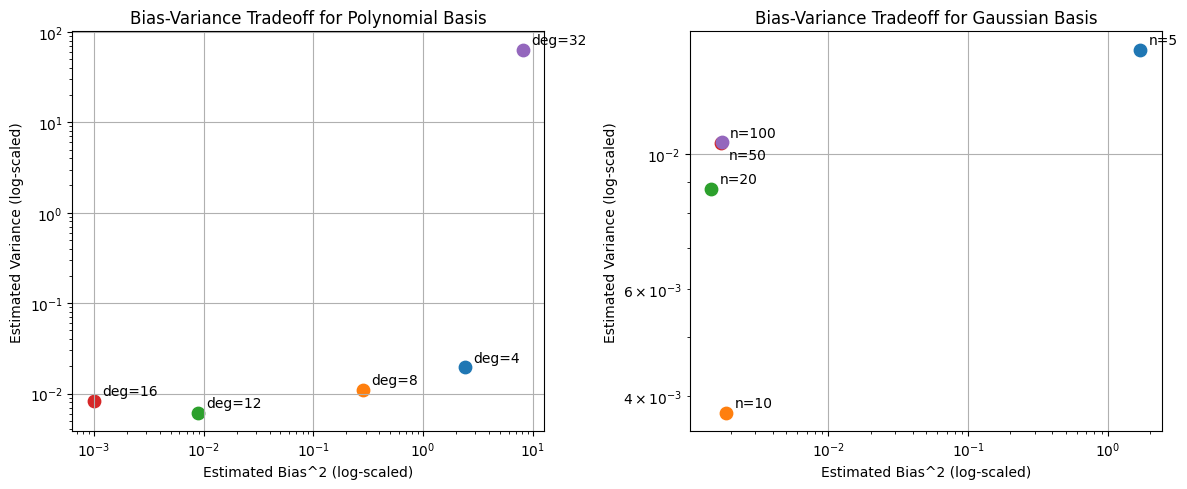

In [11]:
# Q1.5(b)
NUM_DATASETS = 10
N_train = 500
N_test = 1000

poly_degrees = [4, 8, 12, 16, 32]
n_gaussians = [5, 10, 20, 50, 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# TODO: bias2-variance scatter plot for these 10 settings. 
# TODO: plot the polynomial and gaussian basis in two separate subplots.

# TODO: plot the polynomial basis
for degree in poly_degrees:
    b2, var = compute_bias_variance(N_train, NUM_DATASETS, degree=degree, N_test=N_test)
    ax1.scatter(b2, var, s=80)
    ax1.annotate(f'deg={degree}', (b2, var), textcoords='offset points', xytext=(6, 4))

ax1.set_xlabel('Estimated Bias^2 (log-scaled)')
ax1.set_ylabel('Estimated Variance (log-scaled)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Bias-Variance Tradeoff for Polynomial Basis')
ax1.grid()

# gaussian basis

# -----------------------------
### TODO: calculate the gaussian feature matrix
# -----------------------------
def gaussian_features(x, degree=5):
    # degree = number of Gaussian basis functions
    # centers c evenly spaced in [-3, 3], width d=1
    # phi_k(x) = exp(-(x - c_k)^2 / (2 * d^2))
    x = np.asarray(x).reshape(-1)                # shape (N,)
    centers = np.linspace(x_min, x_max, degree)  # shape (degree,)
    d = 1.0
    # shape (N, degree): each column is one basis function evaluated at all x
    return np.exp(-((x[:, None] - centers[None, :]) ** 2) / (2 * d ** 2))

# -----------------------------
### TODO: calculate the MLE solution
# -----------------------------
def theta_MLE_gaussian(x, y, degree):
    # theta = Phi^+ y  (same normal equations, different feature matrix)
    Phi = gaussian_features(x, degree=degree)
    y = np.asarray(y).reshape(-1)
    return np.linalg.pinv(Phi) @ y

offsets = {5: (6, 4), 10: (6, 4), 20: (6, 4), 50: (6, -12), 100: (6, 4)}

### TODO: plot gaussian basis
for n_gaussian in n_gaussians:
    b2, var = compute_bias_variance(
        N_train, NUM_DATASETS,
        feature_fn=lambda x, n=n_gaussian: gaussian_features(x, degree=n),
        mle_fn=lambda x, y, n=n_gaussian: theta_MLE_gaussian(x, y, degree=n),
        N_test=N_test
    )
    ax2.scatter(b2, var, s=80)
    ax2.annotate(f'n={n_gaussian}', (b2, var),
                 textcoords='offset points', xytext=offsets[n_gaussian])

ax2.set_xlabel('Estimated Bias^2 (log-scaled)')
ax2.set_ylabel('Estimated Variance (log-scaled)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Bias-Variance Tradeoff for Gaussian Basis')
ax2.grid()

plt.tight_layout()
plt.show()


Question 1.5(b): Comments on findings

**Polynomial basis** (degrees 4, 8, 12, 16, 32):

As degree increases, bias² decreases monotonically — higher-degree polynomials can fit the target $h(x)$ more closely. However, variance increases sharply with degree. At degree=32, variance becomes extremely large ($\approx 50$) due to numerical near-singularity of $\Phi^\top\Phi$ with 33 parameters: the matrix becomes ill-conditioned, causing the fitted weights to fluctuate wildly across different training datasets. This is a manifestation of the **Runge phenomenon** — high-degree global polynomials oscillate severely near the boundaries $x = \pm 3$.

**Gaussian basis** (n = 5, 10, 20, 50, 100):

The Gaussian basis exhibits the same qualitative bias-variance tradeoff: more basis functions reduce bias but increase variance. However, the variance grows far more gently than for polynomials. Even at $n=100$, variance remains moderate. This is because Gaussian basis functions are **localised** — each $\phi_k(x) = \exp(-(x-c_k)^2/2d^2)$ is non-zero only near its centre $c_k$, so adding more basis functions does not introduce global oscillations. As a result, the condition number of $\Phi^\top\Phi$ stays well-behaved.

**Comparison**:

For the same number of parameters, Gaussian basis functions achieve a better bias-variance trade-off than polynomial basis functions at high complexity. The optimal operating point (lowest bias² + variance) lies at a higher model complexity for Gaussian than for polynomial basis.


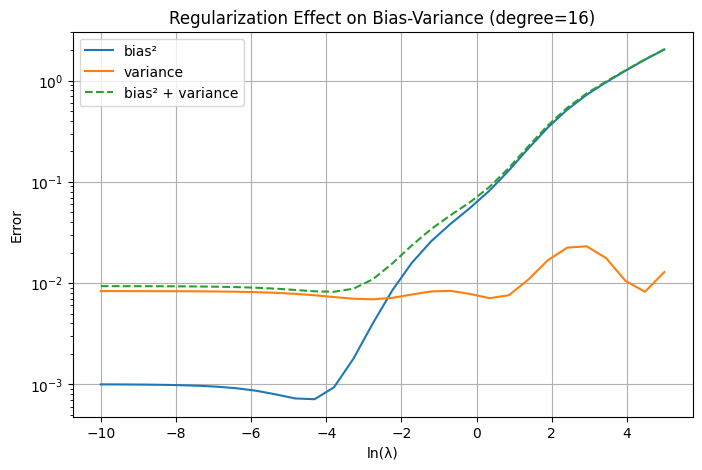

Best ln(λ) = -3.79, λ = 0.0225
bias² = 0.0009, variance = 0.0073


In [12]:
# Q1.5(c)
# TODO: implement a regularized version of MLE
def theta_MLE_regularized(x, y, lbd):
    # Ridge regression: θ = (Φ^T Φ + λI)^{-1} Φ^T y
    # lbd = λ, regularization strength
    Phi = poly_features(x, degree=16)
    y = np.asarray(y).reshape(-1)
    I = np.eye(Phi.shape[1])          # identity matrix, shape (17, 17)
    return np.linalg.solve(Phi.T @ Phi + lbd * I, Phi.T @ y)


poly_degree = 16

# TODO: find a good lambda — scan ln_lambda and plot bias² vs variance
ln_lambdas = np.linspace(-10, 5, 30)   # scan ln(λ) from e^-10 to e^5
lambdas = np.exp(ln_lambdas)

bias2_list, var_list = [], []
for lbd in lambdas:
    b2, var = compute_bias_variance(
        N_train=500, num_datasets=10, N_test=1000,
        feature_fn=lambda x, l=lbd: poly_features(x, degree=poly_degree),
        mle_fn=lambda x, y, l=lbd: theta_MLE_regularized(x, y, lbd=l)
    )
    bias2_list.append(b2)
    var_list.append(var)

# plot bias² and variance vs ln(λ)
plt.figure(figsize=(8, 5))
plt.plot(ln_lambdas, bias2_list, label='bias²')
plt.plot(ln_lambdas, var_list,   label='variance')
plt.plot(ln_lambdas, [b + v for b, v in zip(bias2_list, var_list)], 
         label='bias² + variance', linestyle='--')
plt.xlabel('ln(λ)')
plt.ylabel('Error')
plt.yscale('log')
plt.title('Regularization Effect on Bias-Variance (degree=16)')
plt.legend()
plt.grid()
plt.show()

# find ln(λ) that minimises bias² + variance
total = [b + v for b, v in zip(bias2_list, var_list)]
best_idx = np.argmin(total)
print(f'Best ln(λ) = {ln_lambdas[best_idx]:.2f}, λ = {lambdas[best_idx]:.4f}')
print(f'bias² = {bias2_list[best_idx]:.4f}, variance = {var_list[best_idx]:.4f}')

Question 1.5(c): 

Ridge regression replaces the MLE solution with:

$$\hat{\theta}_\lambda = (\Phi^\top \Phi + \lambda I)^{-1} \Phi^\top y$$

The expected loss decomposes as:

$$\mathbb{E}\left[(t - y(x;\mathcal{D}))^2\right] = (\text{bias})^2 + \text{variance} + \text{noise}$$

Since noise $= \mathbb{E}[(h(x)-t)^2]$ depends only on the data distribution and not on $\lambda$, minimising the expected loss is equivalent to minimising $\widehat{(\text{bias})^2} + \widehat{\text{variance}}$.

By scanning $\ln\lambda \in [-10, 5]$, the minimum of $\widehat{(\text{bias})^2} + \widehat{\text{variance}}$ occurs at $\ln\lambda \approx -4$ ($\lambda \approx 0.018$), giving $\widehat{(\text{bias})^2} \approx 0.0009$ and $\widehat{\text{variance}} \approx 0.0073$. For $\ln\lambda > -4$, bias² rises sharply as the model becomes over-constrained, while variance remains largely unchanged since $N_\text{train}=500$ already stabilises degree=16. This suggests degree=16 requires only mild regularisation at this training set size.


Question 1.5(d):

Regularisation benefits degree=32 the most. The expected loss decomposes as:

$$\mathbb{E}\left[(t - y(x;\mathcal{D}))^2\right] = (\text{bias})^2 + \text{variance} + \text{noise}$$

Regularisation reduces variance at the cost of increasing bias². The potential gain is therefore larger when variance is high. From Q1.5(b), degree=32 produces extremely high variance (≈50) due to numerical instability — $\Phi^\top\Phi$ becomes nearly singular with 33 parameters, causing predictions to fluctuate wildly across datasets. Adding $\lambda I$ improves the condition number of $\Phi^\top\Phi + \lambda I$, directly stabilising the solution.

For lower degrees such as 4 or 8, variance is already small (≈0.01–0.02), so regularisation has little room to improve. The trade-off is unfavourable: any reduction in variance comes with a bias² increase that outweighs the gain.

**Question 1.6**

Question 1.6(a): 

$$
Z \sim \mathcal{N}(0,1), \qquad U=e^{\beta^{-1}Z}, \qquad \beta>0
$$

$$
\Rightarrow \ln U=\beta^{-1}Z \Rightarrow Z=\beta \ln U, \qquad u>0
$$

$$
\because\ u>0 \text{ and } U=e^{\beta^{-1}Z} \text{ is monotone}, \qquad
p_U(u)\,du = p_Z(z)\,dz
$$

$$
\therefore\ p_U(u)=p_Z(z)\left|\frac{dz}{du}\right|
$$

$$
\frac{dz}{du}=\beta \cdot \frac{1}{u}
$$

$$
\therefore\ \left|\frac{dz}{du}\right|=\frac{\beta}{u}, \qquad u>0
$$

$$
\because\ Z\sim\mathcal{N}(0,1), \qquad
p_Z(z)=\frac{1}{\sqrt{2\pi}}\exp\!\left(-\frac{z^2}{2}\right)
$$

$$
\therefore\ p_U(u)
=
\frac{1}{\sqrt{2\pi}}
\exp\!\left(-\frac{z^2}{2}\right)\cdot \frac{\beta}{u}
$$

$$
=
\frac{1}{\sqrt{2\pi}}
\exp\!\left(-\frac{\beta^2(\ln u)^2}{2}\right)\cdot \frac{\beta}{u}
$$

$$
\therefore\ p_U(u)=\frac{\beta}{u\sqrt{2\pi}}
\exp\!\left(-\frac{\beta^2(\ln u)^2}{2}\right), \qquad u>0
$$

$$
p_U(u)=0, \qquad u\le 0
$$

Question 1.6(b): 

$$
\text{Given}
\qquad
p_X(x)=\frac{1}{x\sigma\sqrt{2\pi}}
\exp\!\left(-\frac{(\ln x-\mu)^2}{2\sigma^2}\right)
$$

$$
\text{Use the substitutions}
\qquad
\mu=0,\quad \sigma=\beta^{-1},\quad x=u
$$

$$
p_X(x)
=
\frac{1}{u(\beta^{-1})\sqrt{2\pi}}
\exp\!\left(-\frac{(\ln u-0)^2}{2\beta^{-2}}\right)
$$

$$
=
\frac{\beta}{u\sqrt{2\pi}}
\exp\!\left(-\frac{\beta^2(\ln u)^2}{2}\right)
$$

$$
=
p_U(u)
$$

$$
\therefore\ \text{the two forms are equivalent.}
$$

Question 1.6(c):

$$
y_i = \boldsymbol{\theta}^\top \boldsymbol{\phi}_i + \varepsilon_i
$$

$$
\text{Define}
\qquad
r_i = y_i - \boldsymbol{\theta}^\top \boldsymbol{\phi}_i
$$

$$
\therefore\ r_i = \varepsilon_i
\qquad\text{and}\qquad
|r_i| = |\varepsilon_i|
$$

$$
\because\ |\varepsilon_i| \text{ follows a log-normal distribution,}
$$

$$
p_{\text{lognormal}}(|r_i|)
=
\frac{1}{|r_i|\,\sigma\sqrt{2\pi}}
\exp\!\left(
  -\frac{(\ln|r_i| - \mu)^2}{2\sigma^2}
\right),
\qquad |r_i|>0
$$

$$
\because\ \text{the sign is determined by a fair coin flip},
\qquad
p(r_i)=\frac12\,p_{\text{lognormal}}(|r_i|)
$$

$$
\therefore\ p(y_i \mid \boldsymbol{\phi}_i, \boldsymbol{\theta})
=
\frac{1}{2\,|r_i|\,\sigma\sqrt{2\pi}}
\exp\!\left(
  -\frac{(\ln|r_i| - \mu)^2}{2\sigma^2}
\right)
$$

$$
\because\ \varepsilon_1,\ldots,\varepsilon_n \text{ are independent},
$$

$$
\therefore\ \mathcal{L}(\boldsymbol{\theta})
= \prod_{i=1}^{n} p(y_i \mid \boldsymbol{\phi}_i, \boldsymbol{\theta})
$$

$$
= \prod_{i=1}^{n}
\frac{1}{2\,|r_i|\,\sigma\sqrt{2\pi}}
\exp\!\left(
  -\frac{(\ln|r_i| - \mu)^2}{2\sigma^2}
\right)
$$

$$
\text{Substitute } \mu=-1,\ \sigma=0.5
$$

$$
\therefore\ \mathcal{L}(\boldsymbol{\theta})
= \prod_{i=1}^{n}
\frac{1}{|r_i|\,\sqrt{2\pi}}
\exp\!\left(
  -2\bigl(\ln|r_i| + 1\bigr)^2
\right)
$$

Question 1.6 (d): 

$$
r_i = y_i-\theta^\top \phi_i
$$



$$
\text{From part (c), } \ln L(\theta)
=
\sum_{i=1}^n
\left[
-\ln 2-\ln |r_i|-\ln(\sigma\sqrt{2\pi})
-\frac{(\ln |r_i|-\mu)^2}{2\sigma^2}
\right]
$$

$$
\because\ \frac{\partial r_i}{\partial \theta}=-\phi_i,
\qquad
\frac{\partial \ln |r_i|}{\partial \theta}
=
\frac{1}{r_i}\frac{\partial r_i}{\partial \theta}
=
-\frac{\phi_i}{r_i}
$$

$$
\therefore\ 
\nabla_\theta \ln L(\theta)
=
\sum_{i=1}^n
\left[
\frac{\phi_i}{r_i}
+
\frac{\ln |r_i|-\mu}{\sigma^2\,r_i}\phi_i
\right]
$$

$$
=
\sum_{i=1}^n
\frac{1+\frac{\ln |r_i|-\mu}{\sigma^2}}{r_i}\,\phi_i
$$
$$
\text{Substitute } \mu=-1,\ \sigma=0.5
$$

$$
\nabla_\theta \ln L(\theta)
=
\sum_{i=1}^n
\frac{1+\frac{\ln |r_i|+1}{0.25}}{r_i}\,\phi_i
$$

$$
=
\sum_{i=1}^n
\frac{5+4\ln |r_i|}{r_i}\,\phi_i
$$

$$
\text{where}\qquad r_i=y_i-\theta^\top\phi_i
$$

### Section 2 ###

**Question 2.1**

Given
$$
q(z\mid \eta)=\exp\!\bigl(\eta^\top u(z)-\psi(\eta)\bigr),
\qquad
u(z)=(z,z^2),
\qquad
\eta=\left(\frac{\mu}{\sigma^2},-\frac{1}{2\sigma^2}\right)
$$

we first compute
$$
\eta^\top u(z)
=
\frac{\mu}{\sigma^2}z-\frac{1}{2\sigma^2}z^2
$$

$$
=
-\frac{1}{2\sigma^2}\left(z^2-2\mu z\right)
$$

$$
\because\ 
z^2-2\mu z=(z-\mu)^2-\mu^2
$$

$$
\therefore\ 
\eta^\top u(z)
=
-\frac{(z-\mu)^2}{2\sigma^2}
+\frac{\mu^2}{2\sigma^2}
$$

Now use the definition of the normalizer:
$$
Z(\eta)
=
\int_{-\infty}^{\infty}\exp\!\bigl(\eta^\top u(z)\bigr)\,dz
$$

Substitute the expression above:
$$
Z(\eta)
=
\int_{-\infty}^{\infty}
\exp\!\left(
-\frac{(z-\mu)^2}{2\sigma^2}
+\frac{\mu^2}{2\sigma^2}
\right)\,dz
$$

$$
=
\exp\!\left(\frac{\mu^2}{2\sigma^2}\right)
\int_{-\infty}^{\infty}
\exp\!\left(
-\frac{(z-\mu)^2}{2\sigma^2}
\right)\,dz
$$

Using the Gaussian integral,
$$
\int_{-\infty}^{\infty}
\exp\!\left(
-\frac{(z-\mu)^2}{2\sigma^2}
\right)\,dz
=
\sqrt{2\pi}\,\sigma
$$

we obtain
$$
Z(\eta)
=
\sqrt{2\pi}\,\sigma\,
\exp\!\left(\frac{\mu^2}{2\sigma^2}\right)
$$

Hence
$$
\psi(\eta)=\ln Z(\eta)
$$

$$
\therefore\ 
\psi(\eta)
=
\frac{\mu^2}{2\sigma^2}
+\ln(\sqrt{2\pi}\,\sigma)
$$

Substitute this result back into
$$
q(z\mid\eta)
=
\exp\!\left(
\eta^\top u(z)-\psi(\eta)
\right)
$$

Then
$$
q(z\mid\eta)
=
\exp\!\left(
-\frac{(z-\mu)^2}{2\sigma^2}
+\frac{\mu^2}{2\sigma^2}
-\frac{\mu^2}{2\sigma^2}
-\ln(\sqrt{2\pi}\,\sigma)
\right)
$$

$$
=
\exp\!\left(
-\frac{(z-\mu)^2}{2\sigma^2}
-\ln(\sqrt{2\pi}\,\sigma)
\right)
$$

$$
=
\frac{1}{\sqrt{2\pi}\,\sigma}
\exp\!\left(
-\frac{(z-\mu)^2}{2\sigma^2}
\right)
$$

Therefore
$$
q(z\mid\eta)=\mathcal N(z;\mu,\sigma^2)
$$

So the final results are
$$
\boxed{
\mathrm{Exp}(u,\eta)=\mathcal N(z;\mu,\sigma^2)
}
$$

$$
\boxed{
Z(\eta)=\sqrt{2\pi}\,\sigma\,
\exp\!\left(\frac{\mu^2}{2\sigma^2}\right)
}
$$

$$
\boxed{
\psi(\eta)=\frac{\mu^2}{2\sigma^2}+\ln(\sqrt{2\pi}\,\sigma)
}
$$

**Question 2.2**


Let
$$
f_i := f(x_i;w)
$$

From the question,
$$
u(y)=(y,y^2)
$$

and
$$
\eta(x)=\bigl(f(x;w),-\tfrac12\bigr)
$$

Also,
$$
p(y\mid x;w)
=
q(y\mid \eta(x))
=
\exp\!\bigl(\eta(x)^\top u(y)-\psi(\eta(x))\bigr)
$$

Hence
$$
\eta(x)^\top u(y)
=
f(x;w)\,y-\frac12 y^2
$$

Therefore
$$
p(y\mid x;w)
=
\exp\!\left(
f(x;w)\,y-\frac12 y^2-\psi(\eta(x))
\right)
$$

Complete the square:
$$
f(x;w)\,y-\frac12 y^2
=
-\frac12\left(y^2-2f(x;w)y\right)
$$

Because
$$
y^2-2f(x;w)y
=
\bigl(y-f(x;w)\bigr)^2-f(x;w)^2
$$

we have
$$
f(x;w)\,y-\frac12 y^2
=
-\frac12\bigl(y-f(x;w)\bigr)^2
+\frac12 f(x;w)^2
$$

Now use the definition of the normalizer:
$$
Z(\eta(x))
=
\int_{-\infty}^{\infty}
\exp\!\bigl(\eta(x)^\top u(y)\bigr)\,dy
$$

Substitute the expression above:
$$
Z(\eta(x))
=
\int_{-\infty}^{\infty}
\exp\!\left(
-\frac12\bigl(y-f(x;w)\bigr)^2+\frac12 f(x;w)^2
\right)\,dy
$$

$$
=
\exp\!\left(\frac12 f(x;w)^2\right)
\int_{-\infty}^{\infty}
\exp\!\left(
-\frac12\bigl(y-f(x;w)\bigr)^2
\right)\,dy
$$

Using the Gaussian integral,
$$
\int_{-\infty}^{\infty}
\exp\!\left(
-\frac12\bigl(y-f(x;w)\bigr)^2
\right)\,dy
=
\sqrt{2\pi}
$$

we obtain
$$
Z(\eta(x))
=
\sqrt{2\pi}\,
\exp\!\left(\frac12 f(x;w)^2\right)
$$

Hence
$$
\psi(\eta(x))=\ln Z(\eta(x))
$$

Therefore
$$
\psi(\eta(x))
=
\frac12 f(x;w)^2+\frac12\ln(2\pi)
$$

Substitute this result back into the density:
$$
p(y\mid x;w)
=
\exp\!\left(
f(x;w)\,y-\frac12 y^2-\psi(\eta(x))
\right)
$$

Then
$$
p(y\mid x;w)
=
\exp\!\left(
-\frac12\bigl(y-f(x;w)\bigr)^2
+\frac12 f(x;w)^2
-\frac12 f(x;w)^2
-\frac12\ln(2\pi)
\right)
$$

$$
=
\frac{1}{\sqrt{2\pi}}
\exp\!\left(
-\frac12\bigl(y-f(x;w)\bigr)^2
\right)
$$

For each training sample,
$$
\log p(y_i\mid x_i;w)
=
-\frac12\bigl(y_i-f(x_i;w)\bigr)^2
-\frac12\ln(2\pi)
$$

Summing over all samples,
$$
\sum_{i=1}^N \log p(y_i\mid x_i;w)
=
-\frac12\sum_{i=1}^N \bigl(y_i-f(x_i;w)\bigr)^2
-\frac{N}{2}\ln(2\pi)
$$

The last term does not depend on the parameter vector.

Therefore
$$
\arg\max_{w\in\mathbb R^n}
\sum_{i=1}^N \log p(y_i\mid x_i;w)
=
\arg\min_{w\in\mathbb R^n}
\sum_{i=1}^N \bigl(y_i-f(x_i;w)\bigr)^2
$$

Thus,
$$
\boxed{
\arg\max_{w\in\mathbb R^n}
\sum_{i=1}^N \log p(y_i\mid x_i;w)
=
\arg\min_{w\in\mathbb R^n}
\sum_{i=1}^N \bigl(y_i-f(x_i;w)\bigr)^2
}
$$

Moreover, the derivation uses only the value of
$$
f(x;w)
$$
and does not rely on linearity or any other special algebraic structure.

Therefore the equivalence holds for any parameterized model
$$
f
$$

**Question 2.3**

We have
$$
p(y \mid x; \theta)
=
\exp\!\bigl(\eta^\top u(y) - \psi(\eta)\bigr),
\qquad
\eta = f(x;\theta),
$$

with
$$
Z(\eta)
=
\int \exp\!\bigl(\eta^\top u(y')\bigr)\,dy',
\qquad
\psi(\eta)=\ln Z(\eta).
$$

Here \(y'\) is a dummy integration variable.

Question 2.3(1): 

**Logic in one line:**
$$
\psi(\eta)=\ln Z(\eta)
\;\Rightarrow\;
\frac{\partial \psi(\eta)}{\partial \eta}
=
\frac{1}{Z(\eta)}\frac{\partial Z(\eta)}{\partial \eta}
\;\Rightarrow\;
\mathbb{E}_{p(y\mid x)}[u(y)].
$$

Since
$$
\psi(\eta)=\ln Z(\eta),
$$
we have
$$
\frac{\partial \psi(\eta)}{\partial \eta}
=
\frac{1}{Z(\eta)}
\frac{\partial Z(\eta)}{\partial \eta}.
$$

Also,
$$
Z(\eta)
=
\int \exp\!\bigl(\eta^\top u(y')\bigr)\,dy'.
$$

For
$$
\eta \in \mathrm{int}(P),
$$
the normalizer is finite, so differentiation under the integral sign is valid. Therefore
$$
\frac{\partial Z(\eta)}{\partial \eta}
=
\int
\frac{\partial}{\partial \eta}
\exp\!\bigl(\eta^\top u(y')\bigr)\,dy'
=
\int
u(y')\,\exp\!\bigl(\eta^\top u(y')\bigr)\,dy'.
$$

Substitute this into the previous expression:
$$
\frac{\partial \psi(\eta)}{\partial \eta}
=
\frac{
\int u(y')\,\exp\!\bigl(\eta^\top u(y')\bigr)\,dy'
}{
\int \exp\!\bigl(\eta^\top u(y')\bigr)\,dy'
}.
$$

Now use the definition of the model distribution:
$$
p(y' \mid x;\theta)
=
\frac{\exp\!\bigl(\eta^\top u(y')\bigr)}{Z(\eta)}.
$$

Hence
$$
\frac{\partial \psi(\eta)}{\partial \eta}
=
\int u(y')\,p(y' \mid x;\theta)\,dy'
=
\mathbb{E}_{p(y' \mid x;\theta)}[u(y')].
$$

Evaluating at
$$
\eta=f(x;\theta),
$$
we obtain
$$
\left.
\frac{\partial \psi(\eta)}{\partial \eta}
\right|_{\eta=f(x;\theta)}
=
\mathbb{E}_{p(y \mid x)}[u(y)].
$$

Therefore,
$$
\boxed{
\left.
\frac{\partial \psi(\eta)}{\partial \eta}
\right|_{\eta=f(x;\theta)}
=
\mathbb{E}_{p(y \mid x)}[u(y)]
}
$$

Question 2.3(2): 

**Logic in one line:**
$$
\log p(y\mid x;\theta)=\eta^\top u(y)-\psi(\eta),
\quad
\eta=f(x;\theta)
$$
$$
\Rightarrow\;
\frac{\partial \log p(y\mid x;\theta)}{\partial \eta}
=
u(y)-\mathbb{E}_{p(y'\mid x)}[u(y')]
\;
$$
$$
\Rightarrow\;
\frac{\partial \log p(y\mid x;\theta)}{\partial \theta}
=
\left(
u(y)-\mathbb{E}_{p(y'\mid x)}[u(y')]
\right)^\top
\frac{\partial f(x;\theta)}{\partial \theta}.
$$
Start from
$$
\log p(y \mid x;\theta)
=
\eta^\top u(y)-\psi(\eta),
\qquad
\eta=f(x;\theta).
$$

Differentiate
$$
\frac{\partial \log p(y \mid x;\theta)}{\partial \eta}
=
u(y)-\frac{\partial \psi(\eta)}{\partial \eta}.
$$

Using the result from Part 1,
$$
\frac{\partial \psi(\eta)}{\partial \eta}
=
\mathbb{E}_{p(y' \mid x)}[u(y')],
$$
so
$$
\frac{\partial \log p(y \mid x;\theta)}{\partial \eta}
=
u(y)-\mathbb{E}_{p(y' \mid x)}[u(y')].
$$

Now apply the chain rule:
$$
\frac{\partial \log p(y \mid x;\theta)}{\partial \theta}
=
\left(
\frac{\partial \log p(y \mid x;\theta)}{\partial \eta}
\right)^\top
\left(
\frac{\partial \eta}{\partial \theta}
\right).
$$

Since
$$
\eta=f(x;\theta),
$$
we have
$$
\frac{\partial \eta}{\partial \theta}
=
\frac{\partial f(x;\theta)}{\partial \theta}.
$$


Therefore,
$$
\boxed{
\frac{\partial \log p(y \mid x;\theta)}{\partial \theta}
=
\left(
u(y)-\mathbb{E}_{p(y' \mid x)}[u(y')]
\right)^\top
\left(
\frac{\partial f(x;\theta)}{\partial \theta}
\right)
}
$$

**Question 2.4**

In [13]:
%load_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt

from torch.autograd.functional import jacobian, vjp
from torchvision import datasets, transforms

from framework.exp_fam_model import Model, ExponentialFamily
from framework.mnist_setting import (Multinomial, FC_Model, view_image,
    view_image_pred, view_image_cwr, view_image_rej,
    zero_one_classification_loss)

/opt/miniconda3/envs/marigold/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Please complete below functions:

In [14]:
def grad_psi_wrt_eta(exp_fam: ExponentialFamily, eta: torch.Tensor,
                     batch_size: int) -> torch.Tensor:
    """ Calculate the gradient of the log partition function wrt parameters eta
        (2.8).
        Ensure that this will work for any sized batch

        expected output size: (batch_size, m)
    """
    # General: ∇_η ψ(η) via autograd on exp_fam.log_partition
    # log_partition(eta) → (batch_size,); vjp with ones contracts over batch dim
    # Since samples are independent, row i of result = d psi_i / d eta[i, :]
    _, grad_eta = vjp(exp_fam.log_partition, eta,
                      v=torch.ones(batch_size, device=eta.device, dtype=eta.dtype))
    return grad_eta  # (batch_size, m)

def log_likelihood_grad(exp_fam: ExponentialFamily, model: Model,
                        xs: torch.Tensor, ys: torch.Tensor,
                        theta: torch.Tensor, batch_size: int) -> torch.Tensor:
    """ Calculate the gradient of the log likelihood function wrt model
        parameters (2.9).
        Ensure that this will work for any sized batch

        expected output size: (batch_size, | Theta |) where | Theta | is the
        number of model parameters

        You will need to use vjp -- vector-jacobian-product -- to make this
        efficient.
    """
    with torch.no_grad():
        eta = model.predict(xs, theta)

    residual = (exp_fam.sufficient_statistic(ys)               # u(y), (batch_size, m)
                - grad_psi_wrt_eta(exp_fam, eta, batch_size))  # ∇_η ψ(η), (batch_size, m)

    # Per-sample gradient: one vjp per sample → true (batch_size, |Theta|) semantics
    # Use default arg (x=x_i) to capture x_i by value, avoiding lambda closure bug
    grads = []
    for i in range(batch_size):
        x_i = xs[i:i+1]       # (1, features)
        r_i = residual[i:i+1] # (1, m)
        _, g_i = vjp(lambda t, x=x_i: model.predict(x, t), theta, v=r_i)
        grads.append(g_i)
    return torch.stack(grads, dim=0)  # (batch_size, |Theta|)

def update(exp_fam: ExponentialFamily, model: Model,
           xs: torch.Tensor, ys: torch.Tensor, theta: torch,
           batch_size: int, lr: float = 1e-1) -> torch.Tensor:
    """ Calculate the next set of parameters from a gradient descent update
        step using the log likelihood gradient (2.10).

        expected output size: (| Theta |,) where | Theta | is the
        number of model parameters
    """
    grad = log_likelihood_grad(exp_fam, model, xs, ys, theta, batch_size)
    # gradient ASCENT (+): maximise log-likelihood
    # .detach() prevents computation graph accumulation across batches
    return (theta + lr * grad.mean(dim=0)).detach()


Using the theory introduced in **Q2**, we can define an **exponential-family model** whose natural parameters are produced by a neural network. The code below specifies such an exponential family for a **Multinomial distribution**, which allows us to train a neural network to classify a subset of the **MNIST dataset**.

Once you complete the three functions above, run the training code below. Then execute the final two cells in the notebook and include the outputs:

##### Required Outputs

1. **Training Curve Plot**  
   The plot showing **0–1 loss** on both the **training** and **testing** sets versus **epoch**.

2. **Image-View Prediction Output**  
   The figure produced by:
   ```python
   view_image_pred(view_indices, test_dataset, model, parameters)

In [15]:
train_kwargs = {'batch_size': 256}
test_kwargs = {'batch_size': 1_000}

spec_classes = 5
display_many = 20
class_labels = list(range(spec_classes))

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])
pre_train_dataset = datasets.MNIST('data', train=True,
                    transform=transform)
pre_test_dataset = datasets.MNIST('data', train=False,
                    transform=transform)

indices1 = [i for i, (_, l) in enumerate(pre_train_dataset) \
            if l in class_labels]
indices2 = [i for i, (_, l) in enumerate(pre_test_dataset) \
            if l in class_labels]

train_dataset = torch.utils.data.Subset(pre_train_dataset, indices1)
test_dataset = torch.utils.data.Subset(pre_test_dataset, indices2)

view_indices = torch.randint(0, len(test_dataset), (display_many,)).tolist()

train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

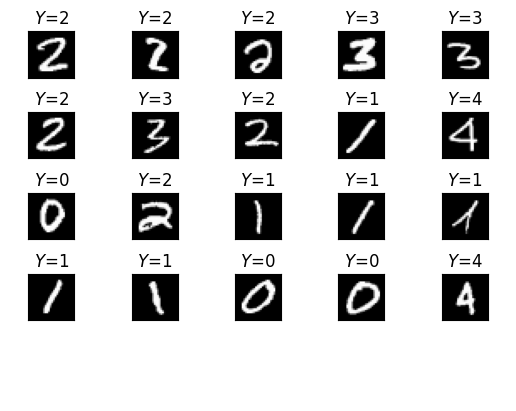

In [24]:
view_image(view_indices, test_dataset)

In [17]:
exp_fam: Multinomial = Multinomial(n_classes = spec_classes)
model: FC_Model = FC_Model(n_classes = spec_classes)
parameters: torch.Tensor = model.make_random_parameter()

In [18]:
epochs = 14
lr = 1
gamma = 0.7

train_hist = []
test_hist = []

def update_hist():
    train_zero_one = 0
    test_zero_one = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        train_zero_one += len(data) * zero_one_classification_loss(
            model, data, target, parameters)
    train_zero_one = train_zero_one / len(train_dataset)

    for batch_idx, (data, target) in enumerate(test_loader):
        test_zero_one += len(data) * zero_one_classification_loss(
            model, data, target, parameters)
    test_zero_one = test_zero_one / len(test_dataset)

    train_hist.append(train_zero_one)
    test_hist.append(test_zero_one)

    return train_zero_one, test_zero_one

train_zero_one, test_zero_one = update_hist()
print(f'Epoch {0} train 0-1: {train_zero_one}; test 0-1: {test_zero_one}')
for e in range(1, epochs+1):
    for batch_idx, (data, target) in enumerate(train_loader):
        parameters = update(exp_fam, model, data, target, parameters, len(data), lr = lr)

    train_zero_one, test_zero_one = update_hist()
    print(f'Epoch {e} train 0-1: {train_zero_one}; test 0-1: {test_zero_one}')

    lr = lr * gamma


Epoch 0 train 0-1: 0.8111518025398254; test 0-1: 0.8054096102714539
Epoch 1 train 0-1: 0.06278598308563232; test 0-1: 0.0669390931725502
Epoch 2 train 0-1: 0.04863381013274193; test 0-1: 0.05837711691856384
Epoch 3 train 0-1: 0.042881421744823456; test 0-1: 0.05409612879157066
Epoch 4 train 0-1: 0.03863250091671944; test 0-1: 0.051955632865428925
Epoch 5 train 0-1: 0.03640998899936676; test 0-1: 0.05137186124920845
Epoch 6 train 0-1: 0.035266049206256866; test 0-1: 0.05000973120331764
Epoch 7 train 0-1: 0.034481629729270935; test 0-1: 0.04923136904835701
Epoch 8 train 0-1: 0.03379526734352112; test 0-1: 0.048842187970876694
Epoch 9 train 0-1: 0.03340305760502815; test 0-1: 0.048647597432136536
Epoch 10 train 0-1: 0.03320695459842682; test 0-1: 0.04806382581591606
Epoch 11 train 0-1: 0.033076219260692596; test 0-1: 0.04806382581591606
Epoch 12 train 0-1: 0.033010851591825485; test 0-1: 0.04806382581591606
Epoch 13 train 0-1: 0.032945483922958374; test 0-1: 0.04806382581591606
Epoch 14 t

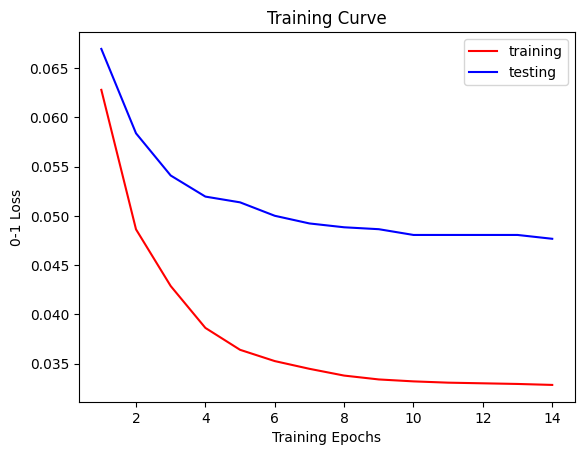

In [25]:
plt.plot(range(1, epochs + 1), train_hist[1:], c='r', label='training')
plt.plot(range(1, epochs + 1), test_hist[1:], c='b', label='testing')

plt.title('Training Curve')
plt.xlabel('Training Epochs')
plt.ylabel('0-1 Loss')
plt.legend()
plt.show()

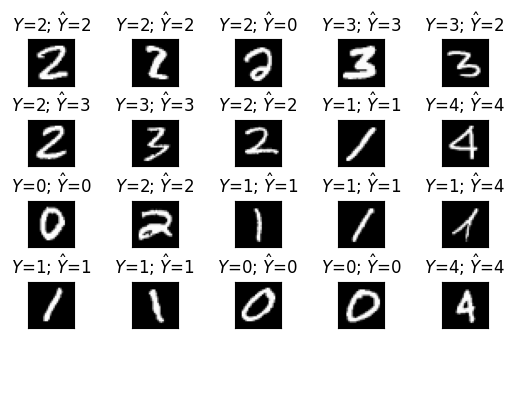

In [26]:
view_image_pred(view_indices, test_dataset, model, parameters)